#PHASE 1: SETUP CODE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Creating Project Folder Structure
import os

BASE_DIR = "/content/drive/MyDrive/NLP_Project"

folders = [
    "datasets",
    "models",
    "results",
    "logs"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [3]:
#installing required libraries
!pip install kagglehub
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install torch torchvision torchaudio
!pip install tqdm

In [3]:
#Importing Libraries

# Core
import os
import json
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, log_loss, matthews_corrcoef
)

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Transformers
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification
)

from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
def save_metrics(metrics, model_name):
    path = os.path.join(BASE_DIR, "results", f"{model_name}_metrics.json")
    with open(path, "w") as f:
        json.dump(metrics, f, indent=4)


def append_results_to_csv(metrics, model_name):
    csv_path = os.path.join(BASE_DIR, "results", "all_models_results.csv")

    metrics["model"] = model_name
    df = pd.DataFrame([metrics])

    if os.path.exists(csv_path):
        df.to_csv(csv_path, mode='a', header=False, index=False)
    else:
        df.to_csv(csv_path, index=False)


def save_model(model, model_name):
    path = os.path.join(BASE_DIR, "models", f"{model_name}.pt")
    torch.save(model.state_dict(), path)


def save_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")

    path = os.path.join(BASE_DIR, "results", f"{model_name}_cm.png")
    plt.savefig(path)
    plt.close()

In [6]:
print("Base directory:", BASE_DIR)
print("Folders:", os.listdir(BASE_DIR))

Base directory: /content/drive/MyDrive/NLP_Project
Folders: ['datasets', 'models', 'results', 'logs']


#PHASE 2: DATA LOADING & PREPARATION

In [8]:
# =========================
# PHASE 2: DATA LOADING & PREPARATION (BINARY)
# =========================

import os
import pandas as pd
import kagglehub
import shutil
from sklearn.model_selection import train_test_split

# -------------------------
# CONFIG
# -------------------------
DATASET_NAME = "davidgauthier/glassdoor-job-reviews"
DATASET_DIR = os.path.join(BASE_DIR, "datasets", "glassdoor")

# -------------------------
# STEP 1: DOWNLOAD (if not already)
# -------------------------
def download_dataset():
    if not os.path.exists(DATASET_DIR):
        print("Downloading dataset...")
        path = kagglehub.dataset_download(DATASET_NAME)
        shutil.copytree(path, DATASET_DIR)
        print("Dataset saved to Drive.")
    else:
        print("Dataset already exists in Drive.")

# -------------------------
# STEP 2: LOAD DATA
# -------------------------
def load_dataset():
    files = [f for f in os.listdir(DATASET_DIR) if f.endswith(".csv")]
    if not files:
        raise Exception("No CSV file found in dataset folder.")

    file_path = os.path.join(DATASET_DIR, files[0])
    print(f"\nLoading file: {files[0]}")

    df = pd.read_csv(file_path)
    return df

# -------------------------
# STEP 3: DATA INSPECTION
# -------------------------
def inspect_data(df):
    print("\n===== DATASET OVERVIEW =====")
    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nSample rows:")
    print(df.head(3))   # keep small

    print("\nMissing values (top 10):")
    print(df.isnull().sum().sort_values(ascending=False).head(10))

# -------------------------
# STEP 4: PREPARE DATA (BINARY SENTIMENT)
# -------------------------
def prepare_data(df):
    # Combine text
    df['review'] = df['pros'].fillna('') + " " + df['cons'].fillna('')

    # Remove neutral reviews
    df = df[df['overall_rating'] != 3].copy()   # ✅ FIX HERE

    # Convert to binary sentiment
    def convert_rating(r):
        if r >= 4:
            return 1
        else:
            return 0

    df['sentiment'] = df['overall_rating'].apply(convert_rating)

    df = df[['review', 'sentiment']]

    df = df.dropna()
    df = df[df['review'].str.strip() != ""]

    return df

# -------------------------
# STEP 5: SPLIT DATA
# -------------------------
def split_data(df):
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df['sentiment'],
        random_state=42
    )
    return train_df, test_df

# -------------------------
# STEP 6: SAVE SPLITS
# -------------------------
def save_splits(train_df, test_df):
    train_path = os.path.join(BASE_DIR, "datasets", "train.csv")
    test_path = os.path.join(BASE_DIR, "datasets", "test.csv")

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print("\nTrain/Test saved to Drive.")

# -------------------------
# STEP 7: RUN PIPELINE
# -------------------------
def run_phase2():
    download_dataset()
    df = load_dataset()

    inspect_data(df)

    df = prepare_data(df)

    print("\n===== AFTER PROCESSING =====")
    print("Shape:", df.shape)

    print("\nClass distribution:")
    print(df['sentiment'].value_counts())

    train_df, test_df = split_data(df)

    print("\nTrain size:", len(train_df))
    print("Test size:", len(test_df))

    save_splits(train_df, test_df)

    return train_df, test_df

# -------------------------
# EXECUTE
# -------------------------
train_df, test_df = run_phase2()

100%|██████████| 83.9M/83.9M [00:07<00:00, 12.1MB/s]

Extracting files...


Dataset saved to Drive.

Loading file: glassdoor_reviews.csv

===== DATASET OVERVIEW =====
Shape: (838566, 18)

Columns:
['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons']

Sample rows:
                    firm date_review              job_title  \
0  AFH-Wealth-Management  2015-04-05                          
1  AFH-Wealth-Management  2015-12-11   Office Administrator   
2  AFH-Wealth-Management  2016-01-28   Office Administrator   

                              current                      location  \
0                    Current Employee                           NaN   
1  Current Employee, more than 1 year  Bromsgrove, England, England   
2  Current Employee, less than 1 year  Bromsgrove, England, England   

   overall_rating  work_life_balance  culture_values  diversity_inclusion  

#PHASE 3: PREPROCESSING PIPELINE

In [9]:
# =========================
# PHASE 3: PREPROCESSING PIPELINE
# =========================

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -------------------------
# BASIC CLEANING (COMMON)
# -------------------------
def basic_clean(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)          # remove HTML
    text = re.sub(r"[^a-zA-Z\s]", "", text)    # keep only letters
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

# -------------------------
# ML PREPROCESSING (FULL)
# -------------------------
def preprocess_ml(text):
    text = basic_clean(text)
    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

# -------------------------
# DL PREPROCESSING (LIGHT)
# -------------------------
def preprocess_dl(text):
    text = basic_clean(text)
    return text   # no stopword removal (important for DL)

# -------------------------
# TRANSFORMER PREPROCESSING
# -------------------------
def preprocess_transformer(text):
    return text.strip()   # keep almost raw

# -------------------------
# APPLY PREPROCESSING
# -------------------------
def apply_preprocessing(train_df, test_df):

    print("Applying ML preprocessing...")
    train_df['ml_text'] = train_df['review'].progress_apply(preprocess_ml)
    test_df['ml_text'] = test_df['review'].progress_apply(preprocess_ml)

    print("Applying DL preprocessing...")
    train_df['dl_text'] = train_df['review'].progress_apply(preprocess_dl)
    test_df['dl_text'] = test_df['review'].progress_apply(preprocess_dl)

    print("Preparing transformer text...")
    train_df['tf_text'] = train_df['review'].progress_apply(preprocess_transformer)
    test_df['tf_text'] = test_df['review'].progress_apply(preprocess_transformer)

    return train_df, test_df

# -------------------------
# LOAD SAVED DATA
# -------------------------
train_path = os.path.join(BASE_DIR, "datasets", "train.csv")
test_path = os.path.join(BASE_DIR, "datasets", "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# -------------------------
# RUN PREPROCESSING
# -------------------------
tqdm.pandas()

train_df, test_df = apply_preprocessing(train_df, test_df)

# -------------------------
# SAVE PROCESSED DATA
# -------------------------
train_df.to_csv(os.path.join(BASE_DIR, "datasets", "train_processed.csv"), index=False)
test_df.to_csv(os.path.join(BASE_DIR, "datasets", "test_processed.csv"), index=False)

print("\nPreprocessing complete and saved!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Applying ML preprocessing...


100%|██████████| 128860/128860 [00:22<00:00, 5616.44it/s]


Applying DL preprocessing...


100%|██████████| 128860/128860 [00:03<00:00, 37529.55it/s]


Preparing transformer text...


100%|██████████| 128860/128860 [00:00<00:00, 1236794.62it/s]



Preprocessing complete and saved!


#PHASE 4: FEATURE ENGINEERING & TOKENIZATION

In [10]:
# =========================
# PHASE 4: FEATURE ENGINEERING (FINAL FIXED)
# =========================

import os
import pickle
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from transformers import BertTokenizer, RobertaTokenizer, DistilBertTokenizer

# -------------------------
# LOAD PROCESSED DATA
# -------------------------
print("Loading processed datasets...")

train_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "train_processed.csv"))
test_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "test_processed.csv"))

# -------------------------
# CLEAN NaNs (CRITICAL FIX)
# -------------------------
print("Cleaning NaN values...")

for col in ['ml_text', 'dl_text', 'tf_text']:
    train_df[col] = train_df[col].fillna("")
    test_df[col] = test_df[col].fillna("")

# -------------------------
# TARGET
# -------------------------
y_train = train_df['sentiment'].values
y_test = test_df['sentiment'].values

print("Data ready!")

# =========================================================
# 🔹 1. TF-IDF (FOR ML MODELS)
# =========================================================
def tfidf_pipeline(train_text, test_text):
    print("\n[1/3] Building TF-IDF (this may take ~1–2 minutes)...")

    vectorizer = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2)
    )

    X_train = vectorizer.fit_transform(train_text)
    print("✔ TF-IDF training complete")

    X_test = vectorizer.transform(test_text)
    print("✔ TF-IDF test transform complete")

    # Save vectorizer
    with open(os.path.join(BASE_DIR, "models", "tfidf_vectorizer.pkl"), "wb") as f:
        pickle.dump(vectorizer, f)

    print("✔ TF-IDF vectorizer saved")
    return X_train, X_test

# =========================================================
# 🔹 2. TOKENIZATION (FOR DL MODELS)
# =========================================================
def dl_tokenization(train_text, test_text):
    print("\n[2/3] Tokenizing for Deep Learning (this may take ~1 min)...")

    tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_text)

    train_seq = tokenizer.texts_to_sequences(train_text)
    test_seq = tokenizer.texts_to_sequences(test_text)

    max_len = 200

    X_train = pad_sequences(train_seq, maxlen=max_len, padding='post')
    X_test = pad_sequences(test_seq, maxlen=max_len, padding='post')

    # Save tokenizer
    with open(os.path.join(BASE_DIR, "models", "dl_tokenizer.pkl"), "wb") as f:
        pickle.dump(tokenizer, f)

    print("✔ DL tokenization complete")
    print("✔ Tokenizer saved")

    return X_train, X_test, max_len

# =========================================================
# 🔹 3. TRANSFORMER TOKENIZERS
# =========================================================
def transformer_tokenizers():
    print("\n[3/3] Loading transformer tokenizers (first time may take ~1–2 min)...")

    bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    print("✔ BERT tokenizer loaded")

    roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
    print("✔ RoBERTa tokenizer loaded")

    distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    print("✔ DistilBERT tokenizer loaded")

    # Save tokenizers
    bert_tokenizer.save_pretrained(os.path.join(BASE_DIR, "models", "bert_tokenizer"))
    roberta_tokenizer.save_pretrained(os.path.join(BASE_DIR, "models", "roberta_tokenizer"))
    distilbert_tokenizer.save_pretrained(os.path.join(BASE_DIR, "models", "distilbert_tokenizer"))

    print("✔ All transformer tokenizers saved")

    return bert_tokenizer, roberta_tokenizer, distilbert_tokenizer

# -------------------------
# RUN ALL PIPELINES
# -------------------------

# TF-IDF
X_train_tfidf, X_test_tfidf = tfidf_pipeline(
    train_df['ml_text'], test_df['ml_text']
)

# DL Tokenization
X_train_dl, X_test_dl, max_len = dl_tokenization(
    train_df['dl_text'], test_df['dl_text']
)

# Transformer Tokenizers
bert_tok, roberta_tok, distilbert_tok = transformer_tokenizers()

print("\n✅ Phase 4 COMPLETE — All features ready!")

Loading processed datasets...
Cleaning NaN values...
Data ready!

[1/3] Building TF-IDF (this may take ~1–2 minutes)...
✔ TF-IDF training complete
✔ TF-IDF test transform complete
✔ TF-IDF vectorizer saved

[2/3] Tokenizing for Deep Learning (this may take ~1 min)...
✔ DL tokenization complete
✔ Tokenizer saved

[3/3] Loading transformer tokenizers (first time may take ~1–2 min)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

✔ RoBERTa tokenizer loaded


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✔ DistilBERT tokenizer loaded
✔ All transformer tokenizers saved

✅ Phase 4 COMPLETE — All features ready!


# PHASE 5: CLASSICAL ML MODELS

In [12]:
# =========================
# PHASE 5: CLASSICAL ML MODELS (UPDATED)
# =========================

import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, log_loss, matthews_corrcoef,
    roc_curve
)

# -------------------------
# LOAD DATA
# -------------------------
print("Loading TF-IDF features...")

with open(os.path.join(BASE_DIR, "models", "tfidf_vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)

train_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "train_processed.csv"))
test_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "test_processed.csv"))

train_df['ml_text'] = train_df['ml_text'].fillna("")
test_df['ml_text'] = test_df['ml_text'].fillna("")

X_train = vectorizer.transform(train_df['ml_text'])
X_test = vectorizer.transform(test_df['ml_text'])

y_train = train_df['sentiment'].values
y_test = test_df['sentiment'].values

print("Data loaded!")

# -------------------------
# METRIC FUNCTION
# -------------------------
def evaluate_model(y_true, y_pred, y_prob=None):
    metrics = {}

    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred)
    metrics['recall'] = recall_score(y_true, y_pred)
    metrics['f1'] = f1_score(y_true, y_pred)
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)

    if y_prob is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        metrics['log_loss'] = log_loss(y_true, y_prob)
        metrics['final_loss'] = metrics['log_loss']  # ✅ added
    else:
        metrics['roc_auc'] = None
        metrics['log_loss'] = None
        metrics['final_loss'] = None

    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm

# -------------------------
# ROC CURVE PLOT
# -------------------------
def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    path = os.path.join(BASE_DIR, "results", f"{model_name}_roc.png")
    plt.savefig(path)
    plt.close()

# -------------------------
# TRAIN FUNCTION
# -------------------------
def train_and_evaluate(model, model_name, use_proba=True):
    print(f"\n🚀 Training {model_name}...")
    start = time.time()

    model.fit(X_train, y_train)

    print("✔ Training done. Predicting...")

    y_pred = model.predict(X_test)

    if use_proba:
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        decision = model.decision_function(X_test)
        y_prob = (decision - decision.min()) / (decision.max() - decision.min())

    metrics, cm = evaluate_model(y_test, y_pred, y_prob)

    end = time.time()
    print(f"⏱ Time taken: {round(end - start, 2)} seconds")

    # -------------------------
    # SAVE EVERYTHING
    # -------------------------
    model_path = os.path.join(BASE_DIR, "models", f"{model_name}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    save_metrics(metrics, model_name)
    append_results_to_csv(metrics, model_name)
    save_confusion_matrix(cm, model_name)

    # ➕ ROC curve
    if y_prob is not None:
        plot_roc_curve(y_test, y_prob, model_name)

    print(f"✔ {model_name} saved + metrics + ROC curve")

    return metrics

# -------------------------
# MODELS
# -------------------------
models = [
    (MultinomialNB(), "Naive_Bayes", True),

    (LogisticRegression(max_iter=1000, class_weight='balanced'),
     "Logistic_Regression", True),

    (LinearSVC(class_weight='balanced'),
     "SVM", False)
]

# -------------------------
# RUN ALL
# -------------------------
all_results = {}

for model, name, use_proba in models:
    metrics = train_and_evaluate(model, name, use_proba)
    all_results[name] = metrics

print("\n✅ PHASE 5 COMPLETE!")

Loading TF-IDF features...
Data loaded!

🚀 Training Naive_Bayes...
✔ Training done. Predicting...
⏱ Time taken: 0.28 seconds
✔ Naive_Bayes saved + metrics + ROC curve

🚀 Training Logistic_Regression...
✔ Training done. Predicting...
⏱ Time taken: 4.56 seconds
✔ Logistic_Regression saved + metrics + ROC curve

🚀 Training SVM...
✔ Training done. Predicting...
⏱ Time taken: 26.3 seconds
✔ SVM saved + metrics + ROC curve

✅ PHASE 5 COMPLETE!


# PHASE 6: DEEP LEARNING MODELS

In [13]:
# =========================
# PHASE 6: DEEP LEARNING MODELS
# =========================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
    roc_curve
)

# -------------------------
# LOAD DATA
# -------------------------
print("Loading DL data...")

train_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "train_processed.csv"))
test_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "test_processed.csv"))

with open(os.path.join(BASE_DIR, "models", "dl_tokenizer.pkl"), "rb") as f:
    tokenizer = pickle.load(f)

def texts_to_padded(texts, tokenizer, max_len=200):
    seq = tokenizer.texts_to_sequences(texts)
    return torch.tensor([s[:max_len] + [0]*(max_len-len(s[:max_len])) for s in seq])

X_train = texts_to_padded(train_df['dl_text'].fillna(""), tokenizer)
X_test = texts_to_padded(test_df['dl_text'].fillna(""), tokenizer)

y_train = train_df['sentiment'].values
y_test = test_df['sentiment'].values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# DATASET
# -------------------------
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, torch.tensor(y_train)), batch_size=64, shuffle=True)
test_loader = DataLoader(TextDataset(X_test, torch.tensor(y_test)), batch_size=64)

# -------------------------
# CLASS WEIGHTS
# -------------------------
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=weights[1])

# -------------------------
# MODEL DEFINITIONS (same)
# -------------------------
class CNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.embedding(x).permute(0,2,1)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze()
        return self.fc(x).squeeze()

class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, 128, batch_first=True)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1]).squeeze()

class GRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, 128, batch_first=True)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, h = self.gru(x)
        return self.fc(h[-1]).squeeze()

# -------------------------
# PLOT FUNCTIONS
# -------------------------
def plot_loss(train_losses, val_losses, name):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.legend()
    plt.title(f"{name} Loss Curve")

    path = os.path.join(BASE_DIR, "results", f"{name}_loss_curve.png")
    plt.savefig(path)
    plt.close()

def plot_roc(y_true, probs, name):
    fpr, tpr, _ = roc_curve(y_true, probs)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.title(f"{name} ROC Curve")

    path = os.path.join(BASE_DIR, "results", f"{name}_roc.png")
    plt.savefig(path)
    plt.close()

# -------------------------
# TRAIN + EVALUATE
# -------------------------
def train_and_evaluate(model, name, epochs=3):
    print(f"\n🚀 Training {name}...")

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"{name} Epoch {epoch+1}")
        for X_batch, y_batch in loop:
            X_batch = X_batch.to(device)
            y_batch = y_batch.float().to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_losses.append(total_loss)

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.float().to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item()

        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={total_loss:.4f}, Val Loss={val_loss:.4f}")

    # -------- FINAL EVAL --------
    preds, probs = [], []

    with torch.no_grad():
        for X_batch, _ in tqdm(test_loader, desc=f"{name} Eval"):
            X_batch = X_batch.to(device)
            logits = model(X_batch)

            prob = torch.sigmoid(logits).cpu().numpy()
            pred = (prob > 0.5).astype(int)

            probs.extend(prob)
            preds.extend(pred)

    # -------- METRICS --------
    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "log_loss": log_loss(y_test, probs),
        "mcc": matthews_corrcoef(y_test, preds),
        "final_loss": val_losses[-1]  # ✅ added
    }

    cm = confusion_matrix(y_test, preds)

    # -------- SAVE --------
    torch.save(model.state_dict(), os.path.join(BASE_DIR, "models", f"{name}.pt"))
    save_metrics(metrics, name)
    append_results_to_csv(metrics, name)
    save_confusion_matrix(cm, name)

    plot_loss(train_losses, val_losses, name)
    plot_roc(y_test, probs, name)

    print(f"✔ {name} complete with graphs!")

# -------------------------
# RUN
# -------------------------
vocab_size = 50000

models = [
    (CNN(vocab_size), "CNN"),
    (LSTM(vocab_size), "LSTM"),
    (GRU(vocab_size), "GRU")
]

for model, name in models:
    train_and_evaluate(model, name)

print("\n✅ Phase 6 COMPLETE!")

Loading DL data...
Using device: cuda

🚀 Training CNN...


CNN Epoch 1: 100%|██████████| 8054/8054 [01:01<00:00, 130.64it/s, loss=0.135]


Epoch 1: Train Loss=1906.7326, Val Loss=431.4215


CNN Epoch 2: 100%|██████████| 8054/8054 [00:58<00:00, 137.12it/s, loss=0.103]


Epoch 2: Train Loss=1552.8099, Val Loss=413.8572


...

Epoch 2: Train Loss=1445.5765, Val Loss=383.2873


GRU Epoch 3: 100%|██████████| 8054/8054 [01:10<00:00, 113.88it/s, loss=0.127]


Epoch 3: Train Loss=1285.7888, Val Loss=387.8387


GRU Eval: 100%|██████████| 2014/2014 [00:04<00:00, 448.38it/s]


✔ GRU complete with graphs!

✅ Phase 6 COMPLETE!


# PHASE 7: TRANSFORMER MODELS


In [14]:
# =========================
# PHASE 7: TRANSFORMERS (FINAL + GRAPHS)
# =========================

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
    roc_curve
)

# -------------------------
# LOAD DATA
# -------------------------
print("Loading transformer data...")

train_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "train_processed.csv"))
test_df = pd.read_csv(os.path.join(BASE_DIR, "datasets", "test_processed.csv"))

# -------------------------
# REDUCE DATA SIZE (CRITICAL)
# -------------------------
print("Reducing dataset size...")

train_df = train_df.sample(n=50000, random_state=42)
test_df = test_df.sample(n=10000, random_state=42)

train_texts = train_df['tf_text'].fillna("").tolist()
test_texts = test_df['tf_text'].fillna("").tolist()

y_train = torch.tensor(train_df['sentiment'].values)
y_test = test_df['sentiment'].values  # numpy for metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# DATASET
# -------------------------
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': self.labels[idx]
        }

# -------------------------
# PLOTS
# -------------------------
def plot_loss(train_losses, val_losses, name):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.legend()
    plt.title(f"{name} Loss Curve")

    path = os.path.join(BASE_DIR, "results", f"{name}_loss_curve.png")
    plt.savefig(path)
    plt.close()

def plot_roc(y_true, probs, name):
    fpr, tpr, _ = roc_curve(y_true, probs)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.title(f"{name} ROC Curve")

    path = os.path.join(BASE_DIR, "results", f"{name}_roc.png")
    plt.savefig(path)
    plt.close()

# -------------------------
# TRAIN + EVAL
# -------------------------
def train_transformer(model, tokenizer, name, epochs=1):
    print(f"\n🚀 Training {name}...")

    train_dataset = TransformerDataset(train_texts, y_train, tokenizer)
    test_dataset = TransformerDataset(test_texts, torch.tensor(y_test), tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16)

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    train_losses = []
    val_losses = []

    # -------- TRAIN --------
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"{name} Epoch {epoch+1}")
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_losses.append(total_loss)

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()

        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={total_loss:.4f}, Val Loss={val_loss:.4f}")

    # -------- FINAL EVAL --------
    preds, probs = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"{name} Eval"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            prob = torch.softmax(logits, dim=1)[:,1]
            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    # -------- METRICS --------
    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "log_loss": log_loss(y_test, probs),
        "mcc": matthews_corrcoef(y_test, preds),
        "final_loss": val_losses[-1]  # ✅ added
    }

    cm = confusion_matrix(y_test, preds)

    # -------- SAVE --------
    torch.save(model.state_dict(), os.path.join(BASE_DIR, "models", f"{name}.pt"))
    save_metrics(metrics, name)
    append_results_to_csv(metrics, name)
    save_confusion_matrix(cm, name)

    plot_loss(train_losses, val_losses, name)
    plot_roc(y_test, probs, name)

    print(f"✔ {name} complete with graphs!")

# -------------------------
# MODELS
# -------------------------
models = [
    ("BERT",
     BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2),
     BertTokenizer.from_pretrained("bert-base-uncased")),

    ("RoBERTa",
     RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2),
     RobertaTokenizer.from_pretrained("roberta-base")),

    ("DistilBERT",
     DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2),
     DistilBertTokenizer.from_pretrained("distilbert-base-uncased"))
]

for name, model, tokenizer in models:
    train_transformer(model, tokenizer, name)

print("\n✅ Phase 7 COMPLETE — Transformers upgraded!")

Loading transformer data...
Reducing dataset size...
Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

✔ RoBERTa complete with graphs!

🚀 Training DistilBERT...


DistilBERT Epoch 1: 100%|██████████| 3125/3125 [10:40<00:00,  4.88it/s, loss=0.284]


Epoch 1: Train Loss=843.4938, Val Loss=148.3505


DistilBERT Eval: 100%|██████████| 625/625 [00:45<00:00, 13.82it/s]


✔ DistilBERT complete with graphs!

✅ Phase 7 COMPLETE — Transformers upgraded!


# PHASE 8: FINAL COMPARISON & ANALYSIS


Models Loaded:


,model,accuracy,precision,recall,f1
0,RoBERTa,0.912800,0.922785,0.972215,0.946855
1,BERT,0.909800,0.937207,0.950814,0.943961
2,DistilBERT,0.905000,0.912178,0.974969,0.942529
3,GRU,0.907962,0.935022,0.949857,0.942381
4,LSTM,0.904330,0.939391,0.939906,0.939649
5,CNN,0.898937,0.928981,0.944676,0.936763
6,Naive_Bayes,0.880095,0.892748,0.964557,0.927264
7,Logistic_Regression,0.855518,0.946518,0.866630,0.904814
8,SVM,0.850877,0.940830,0.866287,0.902021


/tmp/ipykernel_3175/1777307675.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


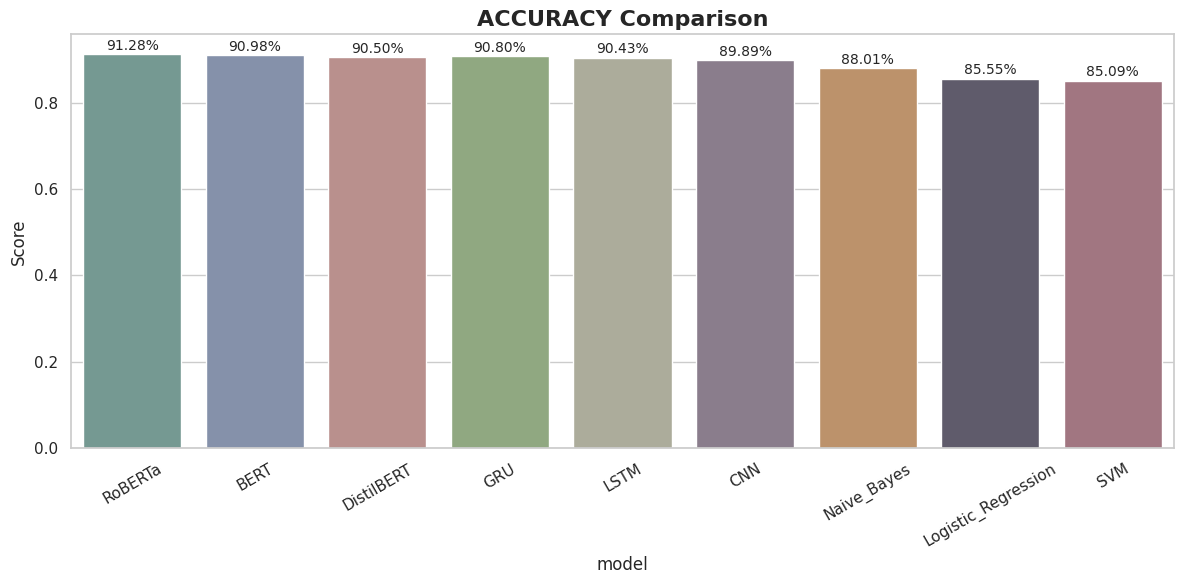

/tmp/ipykernel_3175/1777307675.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


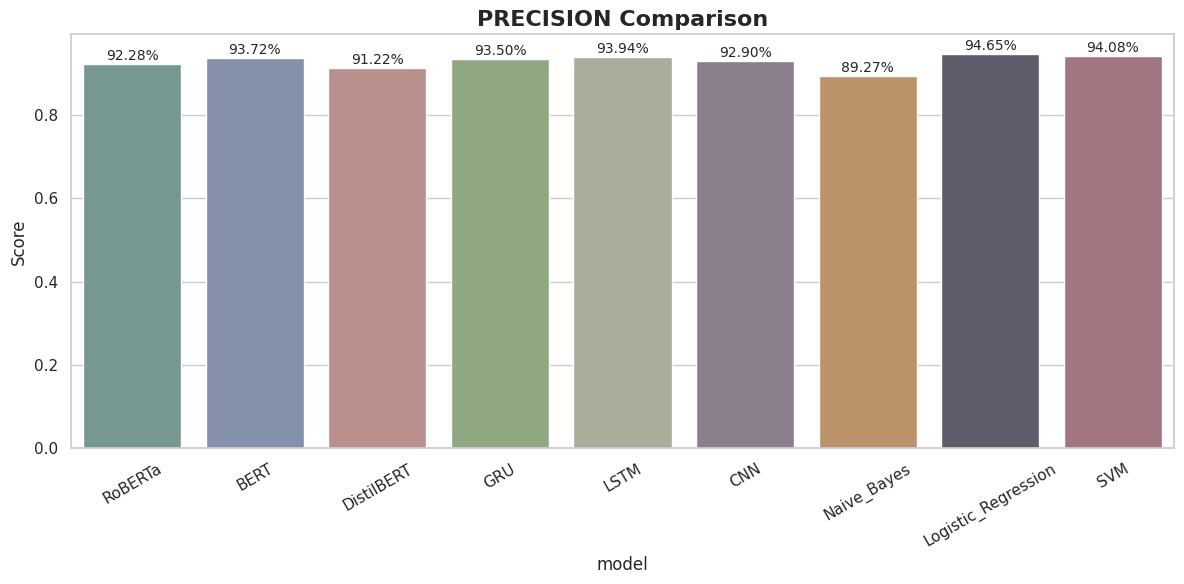

/tmp/ipykernel_3175/1777307675.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


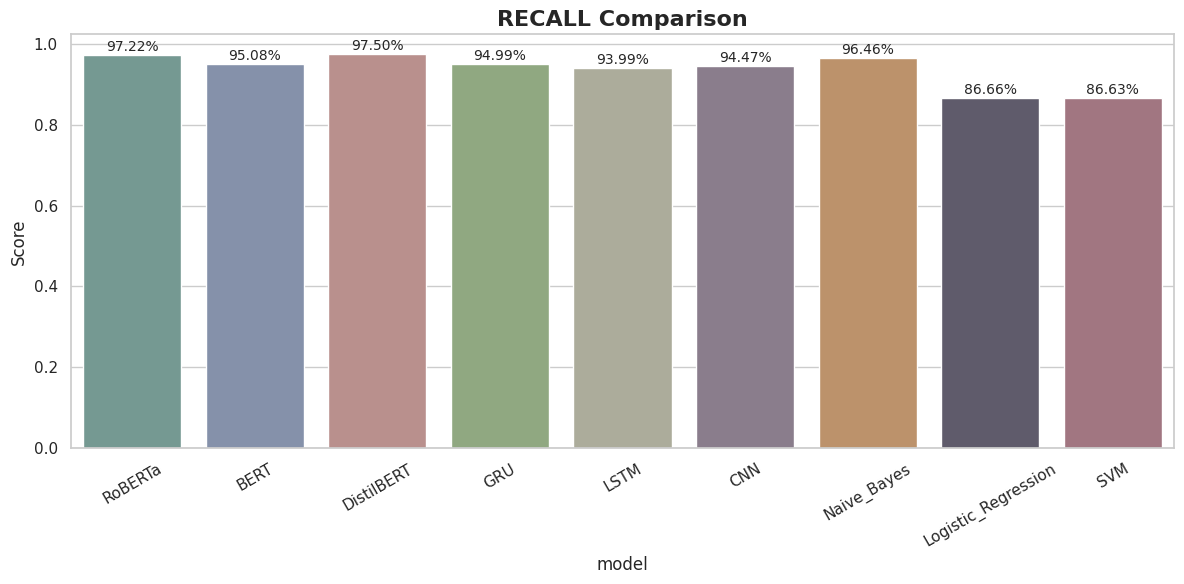

/tmp/ipykernel_3175/1777307675.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


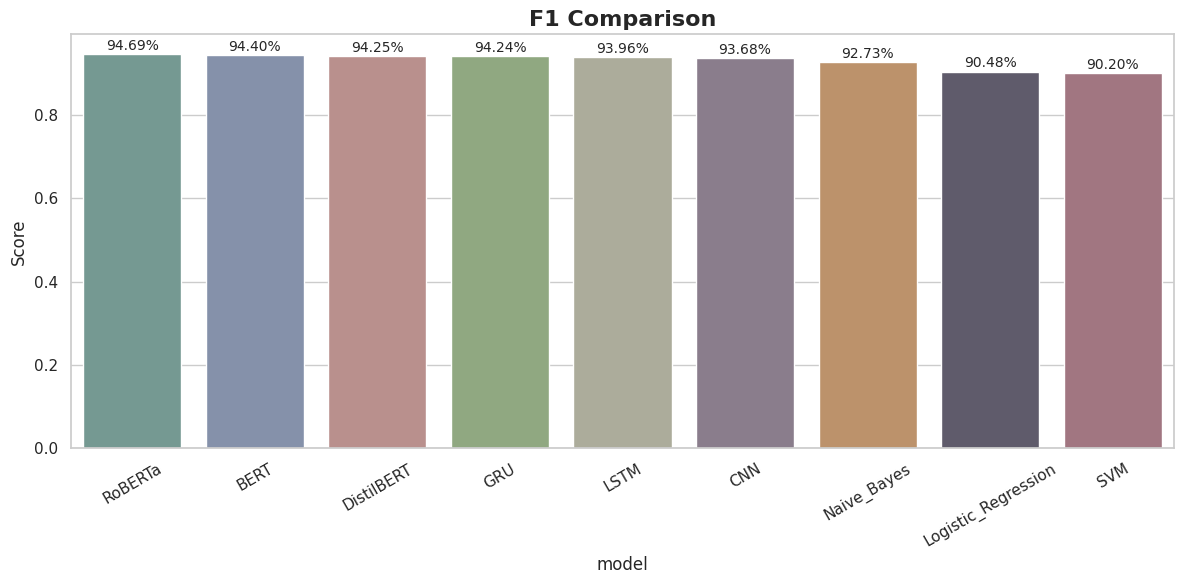

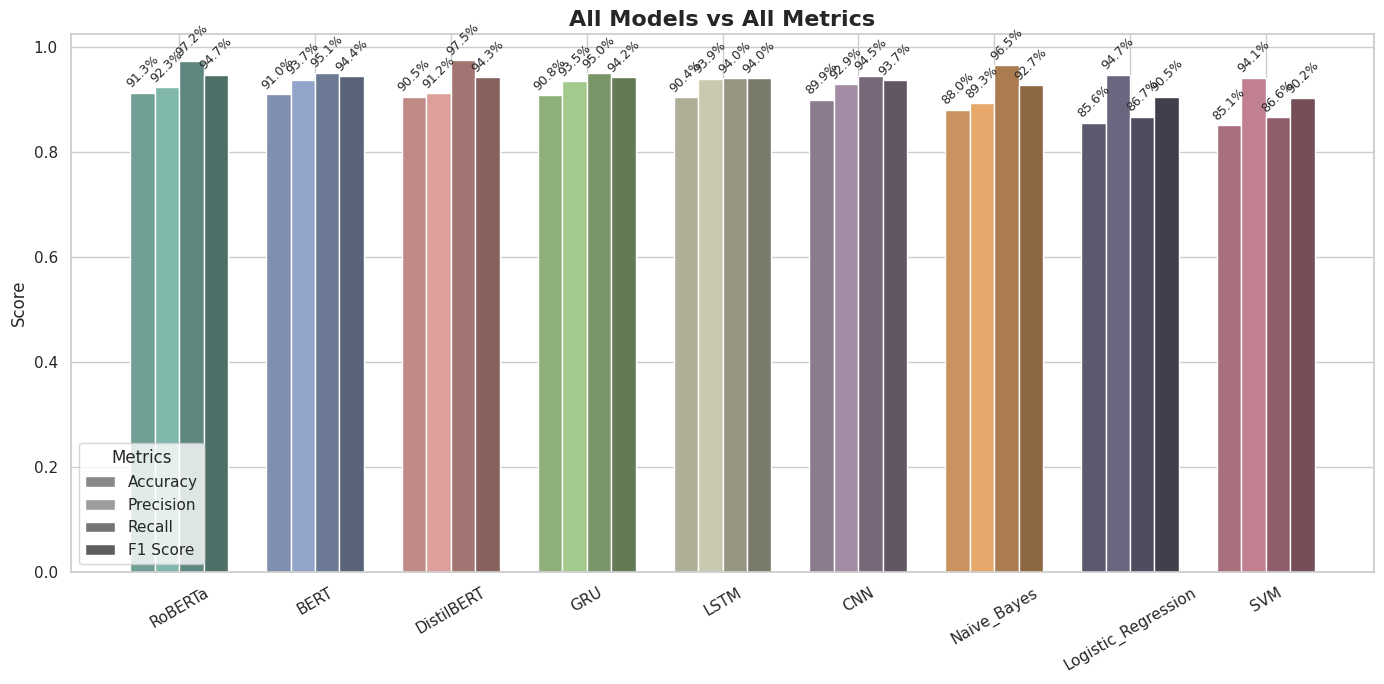

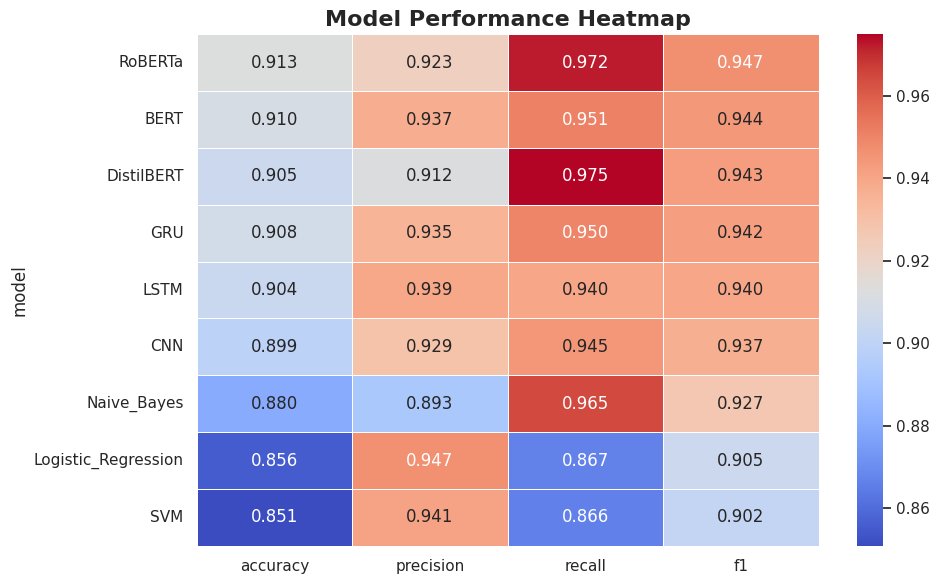


FINAL MODEL RANKING:


,model,accuracy,precision,recall,f1,Rank
0,RoBERTa,0.912800,0.922785,0.972215,0.946855,1
1,BERT,0.909800,0.937207,0.950814,0.943961,2
2,DistilBERT,0.905000,0.912178,0.974969,0.942529,3
3,GRU,0.907962,0.935022,0.949857,0.942381,4
4,LSTM,0.904330,0.939391,0.939906,0.939649,5
5,CNN,0.898937,0.928981,0.944676,0.936763,6
6,Naive_Bayes,0.880095,0.892748,0.964557,0.927264,7
7,Logistic_Regression,0.855518,0.946518,0.866630,0.904814,8
8,SVM,0.850877,0.940830,0.866287,0.902021,9



BEST MODEL: RoBERTa

Accuracy: 0.9128
Precision: 0.9228
Recall: 0.9722
F1 Score: 0.9469



In [11]:
# =========================
# PHASE 8: FINAL VISUAL ANALYTICS
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

sns.set(style="whitegrid")

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv(os.path.join(BASE_DIR, "results", "all_models_results.csv"))
df = df.drop_duplicates(subset=["model"])

df = df[["model", "accuracy", "precision", "recall", "f1"]]
df = df.sort_values(by="f1", ascending=False).reset_index(drop=True)

print("Models Loaded:")
display(df)

# -------------------------
# COLOR PALETTE (ENHANCED MUTED)
# -------------------------
muted_colors = [
    "#6F9F95",
    "#7F8FB0",
    "#C08A86",
    "#8FAF7A",
    "#AFAF98",
    "#8C7A8F",
    "#C9925E",
    "#5E586E",
    "#A86F7D"
]

# -------------------------
# HELPER: SHADE ADJUSTMENT
# -------------------------
def adjust_color(color, factor):
    c = np.array(mcolors.to_rgb(color))
    return np.clip(c * factor, 0, 1)

# -------------------------
# INDIVIDUAL METRIC PLOTS
# -------------------------
def fancy_bar(metric):

    plt.figure(figsize=(12,6))

    sns.barplot(
        x="model",
        y=metric,
        data=df,
        palette=muted_colors[:len(df)]
    )

    for i, v in enumerate(df[metric]):
        plt.text(i, v + 0.01,
                 f"{v*100:.2f}%",
                 ha='center',
                 fontsize=10)

    plt.title(f"{metric.upper()} Comparison", fontsize=16, weight='bold')
    plt.xticks(rotation=30)
    plt.ylabel("Score")

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, "results", f"{metric}_final.png"))
    plt.show()

for metric in ["accuracy", "precision", "recall", "f1"]:
    fancy_bar(metric)

# -------------------------
# 🔥 GROUPED BAR (FINAL FIXED)
# -------------------------
plt.figure(figsize=(14,7))

metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

bar_width = 0.18
x = np.arange(len(df))

# Shade variations (IMPORTANT)
shade_factors = [1.0, 1.15, 0.85, 0.7]

for i, row in df.iterrows():

    base_color = muted_colors[i % len(muted_colors)]

    values = [
        row["accuracy"],
        row["precision"],
        row["recall"],
        row["f1"]
    ]

    for j, v in enumerate(values):

        color = adjust_color(base_color, shade_factors[j])

        plt.bar(
            x[i] + j*bar_width,
            v,
            width=bar_width,
            color=color
        )

        # Value labels
        plt.text(
            x[i] + j*bar_width,
            v + 0.01,
            f"{v*100:.1f}%",
            ha='center',
            rotation=45,
            fontsize=9
        )

# X labels
plt.xticks(x + bar_width*1.5, df["model"], rotation=30)

plt.title("All Models vs All Metrics", fontsize=16, weight='bold')
plt.ylabel("Score")

# -------------------------
# LEGEND (METRICS)
# -------------------------
legend_elements = [
    Patch(facecolor=adjust_color("#888888", shade_factors[i]), label=metric_labels[i])
    for i in range(4)
]

plt.legend(handles=legend_elements, title="Metrics")

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "results", "grouped_metrics.png"))
plt.show()

# -------------------------
# HEATMAP
# -------------------------
plt.figure(figsize=(10,6))

heat_df = df.set_index("model")

sns.heatmap(
    heat_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Model Performance Heatmap", fontsize=16, weight='bold')
plt.tight_layout()

plt.savefig(os.path.join(BASE_DIR, "results", "heatmap_final.png"))
plt.show()

# -------------------------
# FINAL RANKING
# -------------------------
ranking = df.copy()
ranking["Rank"] = ranking.index + 1

print("\nFINAL MODEL RANKING:")
display(ranking)

ranking.to_csv(os.path.join(BASE_DIR, "results", "final_model_ranking.csv"), index=False)

# -------------------------
# SUMMARY
# -------------------------
best = ranking.iloc[0]

summary = f"""
BEST MODEL: {best['model']}

Accuracy: {best['accuracy']:.4f}
Precision: {best['precision']:.4f}
Recall: {best['recall']:.4f}
F1 Score: {best['f1']:.4f}
"""

print(summary)

with open(os.path.join(BASE_DIR, "results", "final_summary.txt"), "w") as f:
    f.write(summary)

